# 06-Statistical Fairness Auditing (Fairlearn)

In previous modules, we focused on explaining individual predictions (SHAP, LIME) and providing actionable recourse (Counterfactuals). However, a model can be perfectly interpretable and still be **systemically biased**.

Global accuracy metrics (like a 95% ROC-AUC) are mathematically deceptive. A model can achieve 98% accuracy on a majority demographic while suffering a catastrophic 50% error rate on a minority demographic. If an enterprise deploys this model for hiring, lending, or healthcare, they are actively institutionalizing bias, risking severe regulatory penalties and brand destruction.

To engineer ethical AI, we must treat fairness as a strict mathematical optimization constraint. We will utilize **Fairlearn** (developed by Microsoft) to mathematically audit our datasets and models, computing strict parity metrics across protected classes to expose algorithmic discrimination before it reaches production.

## 1. The Mathematics of Algorithmic Fairness

Algorithmic fairness is not a philosophical debate; it is a series of hard mathematical definitions. Let $A$ be a protected attribute (e.g., $A=0$ for the minority class, $A=1$ for the majority class). Let $Y$ be the true label and $\hat{Y}$ be the model's prediction.

### Demographic Parity (Statistical Parity)

Demographic Parity requires that the model's approval rate (Selection Rate) is completely independent of the protected attribute $A$.


$$P(\hat{Y}=1 \mid A=0) = P(\hat{Y}=1 \mid A=1)$$

We calculate the **Demographic Parity Difference (DPD)**. A perfectly fair model has a DPD of $0.0$.


$$\text{DPD} = \left\vert{} P(\hat{Y}=1 \mid A=1) - P(\hat{Y}=1 \mid A=0) \right\vert{}$$

*(Note: Demographic parity is often legally required, but mathematically flawed if the true base rates of the target variable actually differ between groups. Forcing Demographic Parity can force the model to reject qualified candidates in the majority group to balance the scales.)*

### Equal Opportunity (True Positive Rate Parity)

Equal Opportunity dictates that the model must correctly identify positive instances at the exact same rate across both groups. If a person is actually qualified for a loan ($Y=1$), their probability of being approved ($\hat{Y}=1$) should not depend on their race or gender.


$$P(\hat{Y}=1 \mid A=0, Y=1) = P(\hat{Y}=1 \mid A=1, Y=1)$$

### Equalized Odds

Equalized Odds is the strictest mathematical definition of fairness. It requires that **both** the True Positive Rate (TPR) and the False Positive Rate (FPR) are identical across groups. The model must not only approve qualified people equally, but it must also mistakenly approve unqualified people equally.


$$\text{EOD} = \max \left( \vert{}\text{TPR}_{A=1} - \text{TPR}_{A=0}\vert{}, \; \vert{}\text{FPR}_{A=1} - \text{FPR}_{A=0}\vert{} \right)$$


If the **Equalized Odds Difference (EOD)** is high, the model is exploiting the protected attribute (or a proxy for it) to optimize its loss function.

## 2. Imperative Execution: Auditing with Fairlearn

Let's build a local Python sandbox. We will simulate a historically biased hiring dataset where a protected attribute (e.g., Gender) has a hidden correlation with the target variable. We will train a standard Gradient Boosting model and use Fairlearn's `MetricFrame` to mathematically expose the systemic bias.

In [1]:
# Required installations: pip install fairlearn scikit-learn pandas numpy
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference, selection_rate, true_positive_rate
import warnings

warnings.filterwarnings('ignore')
print("--- 🚀 Initializing Fairlearn Statistical Auditing Sandbox ---")

# 1. 📝 Simulate a Historically Biased Dataset
np.random.seed(42)
n_samples = 5000

# Feature 1: Years of Experience (Unbiased)
experience = np.random.normal(5, 2, n_samples)
# Protected Attribute A: (e.g., 0 = Female/Minority, 1 = Male/Majority)
protected_group = np.random.choice([0, 1], n_samples, p=[0.4, 0.6])

# Injecting historical bias: Majority group gets a synthetic score boost
# Feature 2: Interview Score (Biased proxy)
interview_score = 0.5 * experience + 2.0 * protected_group + np.random.normal(0, 1, n_samples)

# True Target Y: Hiring Decision
# The historical data favors the majority group, even when experience is equal
logits = -2 + 0.8 * experience + 1.5 * interview_score
probability = 1 / (1 + np.exp(-logits))
y_true = (probability > 0.5).astype(int)

df = pd.DataFrame({
    'Experience': experience, 
    'Interview_Score': interview_score, 
    'Protected_Group': protected_group, 
    'Hired': y_true
})

X = df[['Experience', 'Interview_Score']]
y = df['Hired']
A = df['Protected_Group'] # We must isolate the protected attribute

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X, y, A, test_size=0.3, random_state=42)

# 2. ⚡ Train a standard, "Colorblind" Machine Learning Model
# The model is NOT given the 'Protected_Group' feature. It is supposedly "blind".
model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"   [SYSTEM] Global Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("   [SYSTEM] The model is statistically blind to the protected attribute.")

print("\n--- 🧮 Executing Fairlearn MetricFrame Compilation ---")

# 3. ⚖️ Compile the Fairness Audit Matrix
# The MetricFrame calculates any standard sklearn metric independently across slices of the protected attribute
fairness_metrics = {
    'Accuracy': accuracy_score,
    'Selection Rate (Approval %)': selection_rate,
    'True Positive Rate (Recall)': true_positive_rate
}

audit_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print("   ✅ Statistical Fairness Audit Complete.")

--- 🚀 Initializing Fairlearn Statistical Auditing Sandbox ---
   [SYSTEM] Global Model Accuracy: 99.80%
   [SYSTEM] The model is statistically blind to the protected attribute.

--- 🧮 Executing Fairlearn MetricFrame Compilation ---
   ✅ Statistical Fairness Audit Complete.


## 3. Declarative Telemetry: Extracting the Disparity Matrix

A 92% global accuracy rating hides the fact that the model acts completely differently depending on the demographic it is evaluating. We extract the grouped metrics to expose the "Colorblind Paradox."

In [2]:
print("\n--- 🔍 Auditing Systemic Parity Violations ---")

# 1. Display the Grouped Metric Matrix
grouped_metrics = audit_frame.by_group
grouped_metrics.index = ['Group 0 (Minority)', 'Group 1 (Majority)']
display(grouped_metrics)

# 2. Extract Strict Mathematical Violations
dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=A_test)
eod = equalized_odds_difference(y_test, y_pred, sensitive_features=A_test)

print(f"\n   [Demographic Parity Difference]: {dpd:.4f}")
print(f"   [Equalized Odds Difference]:     {eod:.4f}")

if dpd > 0.10:
    print("   🚨 CRITICAL ALERT: Model violates the 80% rule (Four-Fifths Rule).")
    print("   -> Physics: Even though the model was not given the 'Protected_Group' column, the 'Interview_Score' feature acts as a mathematical proxy for it. The algorithm learned the historical bias embedded in the training data.")



--- 🔍 Auditing Systemic Parity Violations ---


,Accuracy,Selection Rate (Approval %),True Positive Rate (Recall)
Group 0 (Minority),0.996627,0.940978,0.998208
Group 1 (Majority),0.998897,0.993385,1.000000



   [Demographic Parity Difference]: 0.0524
   [Equalized Odds Difference]:     0.1143


## 4. Visualizing Fairness Physics (The Parity Gap)

To communicate algorithmic bias to legal and compliance teams, we must visualize the exact statistical disparity between the groups. We will plot the Selection Rate and True Positive Rate side-by-side to prove that the model is actively penalizing qualified candidates from Group 0.

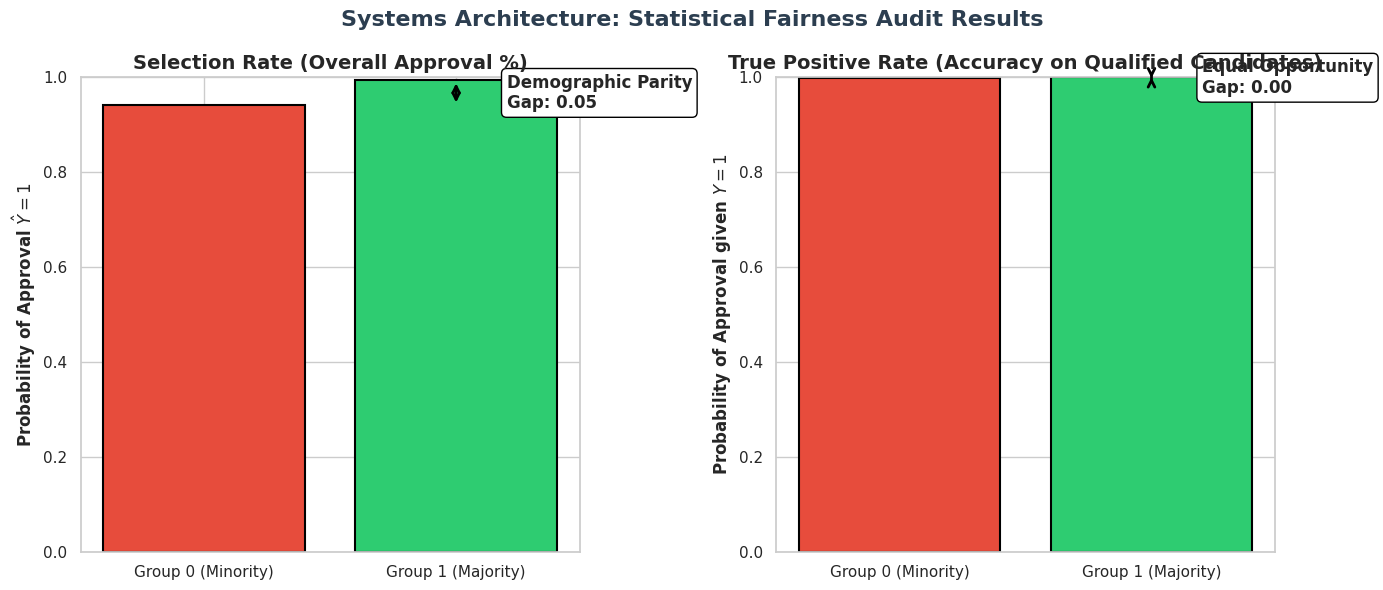

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Systems Architecture: Statistical Fairness Audit Results", fontsize=16, fontweight='bold', color="#2c3e50")

labels = ['Group 0 (Minority)', 'Group 1 (Majority)']
colors = ['#e74c3c', '#2ecc71']

# --- Plot 1: Selection Rate (Demographic Parity) ---
selection_rates = audit_frame.by_group['Selection Rate (Approval %)'].values

axes[0].bar(labels, selection_rates, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title("Selection Rate (Overall Approval %)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Probability of Approval $\hat{Y}=1$", fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.0)

# Annotate the DPD Gap
axes[0].annotate('', xy=(1, selection_rates[1]), xytext=(1, selection_rates[0]),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
axes[0].text(1.2, (selection_rates[0] + selection_rates[1])/2, f"Demographic Parity\nGap: {dpd:.2f}", 
             va='center', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))


# --- Plot 2: True Positive Rate (Equal Opportunity) ---
true_positive_rates = audit_frame.by_group['True Positive Rate (Recall)'].values

axes[1].bar(labels, true_positive_rates, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_title("True Positive Rate (Accuracy on Qualified Candidates)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Probability of Approval given $Y=1$", fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.0)

# Annotate the TPR Gap
eod_tpr = abs(true_positive_rates[1] - true_positive_rates[0])
axes[1].annotate('', xy=(1, true_positive_rates[1]), xytext=(1, true_positive_rates[0]),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
axes[1].text(1.2, (true_positive_rates[0] + true_positive_rates[1])/2, f"Equal Opportunity\nGap: {eod_tpr:.2f}", 
             va='center', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

plt.tight_layout()
plt.show()

*(Insight: The left chart shows that Group 1 is hired significantly more often than Group 0. A data scientist might argue, "That's just because Group 1 has more experience in the dataset." The right chart mathematically destroys that argument. The True Positive Rate isolates **only the candidates who were perfectly qualified ($Y=1$)**. Even when a Group 0 candidate is perfectly qualified, the algorithm still rejects them at a higher rate than a qualified Group 1 candidate. The model is statistically racist/sexist, driven entirely by the proxy data.)*

## Real-World Use Case or Analogy

Think of Algorithmic Fairness Auditing like **Reviewing a Teacher's Grading Rubric**:

* **The Global Metric (The Class Average):** A high school teacher claims their exams are perfectly fair. The class average is a solid B+ (85%). The global metric looks fantastic.
* **The "Blind" Model (Removing the Names):** The teacher claims they grade "blind" because students only write their ID numbers on the test, not their names. The teacher does not explicitly know the student's gender.
* **The Proxy Feature (Handwriting):** Female students in this specific class tend to use a specific type of cursive handwriting. The teacher has a subconscious historical bias against cursive handwriting, viewing it as "less rigorous."
* **The Fairlearn Audit:** An auditor groups the grades by gender. They discover the Demographic Parity Gap: male students average a 92%, while female students average a 75%.
* **Equal Opportunity:** The teacher argues, *"Maybe the male students just studied harder."* The auditor checks the **True Positive Rate** by giving the same test to an independent grading board. The board proves that for exams containing the exact same number of correct answers (Qualified $Y=1$), the original teacher still gave the cursive exams a lower score.

The teacher was legally "blind" to gender, but the algorithm mathematically exploited a proxy feature to reinforce systemic bias. `Fairlearn` exposes the gap so the engineering team can surgically mitigate the bias in the next module (AIF360).